# ChessPublishing Atom Extraction — Working Notebook

Iterate on extraction prompt + JSONL format using real examples from the generated data.

**Input:** `data/chesspublishinga.jsonl`

---
## Setup & Data Loading

In [63]:
import os
import json
import random
import chess
import chess.svg
import openai
from IPython.display import display, SVG, Markdown
from dotenv import load_dotenv

load_dotenv()

DATA_FILE = 'data/chesspublishinga.jsonl'

def parse_json_output(text):
    text = text.strip()
    if text.startswith('```'):
        text = text.split('\n', 1)[1]
        if text.endswith('```'):
            text = text[:-3]
        text = text.strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return {"include": False, "exclude_reason": "JSON parse error", "raw": text}

print(f'Data: {DATA_FILE}')

Data: data/chesspublishinga.jsonl


In [64]:
with open(DATA_FILE) as f:
    all_entries = [json.loads(line) for line in f]

# Filter out game-level comments (no move) — we only extract atoms for moves
all_entries = [e for e in all_entries if e.get('move_uci')]

print(f'Loaded {len(all_entries)} entries from {DATA_FILE}')

Loaded 194434 entries from data/chesspublishinga.jsonl


---
## Extraction Prompt & Demos

System prompt, few-shot demos, and helper functions for the extraction LLM call.

In [ ]:
SYSTEM_PROMPT = """\
You are extracting structured move explanations from chess commentary.

You will receive: a FEN, the move played, previous moves for context,
a context_fen, and the annotator's commentary.

For VARIATION entries (sidelines), you will also receive:
- mainline_move: the move the game actually played (this entry discusses
  an alternative)
- parent_comment: framing context from the annotator on the parent move

Your job is to EXTRACT and STRUCTURE the commentary into a JSON object.

Output ONLY valid JSON. No preamble, no markdown fences, no explanation.

When include=true, output:
{
  "include": true,
  "fen": "<FEN of the position>",
  "move_san": "<the move>",
  "move_uci": "<UCI of that move>",
  "book_commentary": "<the full original commentary>",
  "reasoning": ["atomic fact 1", "atomic fact 2"],
  "variation": "19...Bxf6 gxf6 20.Rg4+ ...",
  "alternative": {
    "move": "Qxh7+",
    "reasoning": ["why it's worse/better"],
    "variation": "18.Qxh7+ Kf8 ..."
  }
}

When include=false, output ONLY:
{
  "include": false,
  "exclude_reason": "short explanation",
  "book_commentary": "<the full original commentary>"
}

MOVE ATTRIBUTION:
The commentary may explain a PREVIOUS move, not the tagged move.
Use the prev_moves + context_fen to determine which move the commentary
is actually about. The output fen/move_san/move_uci MUST correspond to
the position and move the commentary explains.

ATOM RULES:

1. Each reasoning atom explains something about the CURRENT MOVE from
   the CURRENT FEN. A model will be given only the FEN + move and must
   generate these atoms — so they must make sense in that context alone.

2. STRICT EXTRACTION. Extract ONLY what the commentary explicitly says.
   Do NOT invent, infer, or enrich with your own chess analysis.
   If the commentary says "well timed" but doesn't explain why, that
   is NOT enough — exclude it. The atoms must come from the text.

3. Each atom must explain WHAT the move DOES — a threat it creates, a
   square it controls, a piece it activates, a plan it enables.
   GOOD: "Qd4 prevents Black's rooks from reaching the central files."
   GOOD: "d5 prevents White from playing e4."
   BAD:  "Nd4 is a strong resource for White." (vague label)
   BAD:  "Rg8 allows Black to hold on." (doesn't say what Rg8 does)
   BAD:  "Be5 is presented as a standard idea." (meta-description)

4. Short illustrative lines in atoms are fine to show a threat or idea
   (e.g. "Bxd4 threatens Bxf6 gxf6, Rg4+ with a mating attack").
   Long multi-move variations (5+ moves) belong in the "variation" field,
   NOT inside atoms.

5. Do NOT prefix atoms with preceding moves from earlier in the game.
   The atom must be about the position in the FEN, not how we got there.

6. Group logically connected setup+consequence into a SINGLE atom.

7. Name squares, pieces, and diagonals concretely.

8. DROP VAGUE LABELS. Silently drop phrases that are merely evaluative
   labels — even when the entry has other good atoms. Examples to drop:
   "The move is committal", "A slightly passive choice",
   "This keeps the tension", "A practical decision",
   "A strong resource", "Other moves bring no problems".

9. INCLUDE/EXCLUDE.
   EXCLUDE when:
   - The commentary contains NO concrete facts about what the move does
     (only labels like "well timed", "natural", "a good move")
   - Commentary only shows a variation line with no explanation of WHY
     the move works (a bare line + "holds"/"nothing clear"/"wins" is
     NOT an explanation)
   - Historical anecdotes, biographies, game references with no analysis
   INCLUDE when there is at least one concrete fact about what the move
   does — a specific square, piece, threat, file, diagonal, or plan.
   "(stopping e4)" is enough. "well timed" is not.

10. NEVER include generic philosophical statements as atoms.

11. For sidelines: the alternative field captures the MAINLINE move that
    the annotator is comparing against, if they discuss it.
"""

print(f'System prompt: {len(SYSTEM_PROMPT)} chars')

In [66]:
# ── Hardcoded demo data (from Chernev's Logical Chess) ──────────────────
# These are 3 Chernev demos for few-shot extraction. No engine data needed.

DEMO_DATA = [
    # Demo 1: Qe5 — tactical (pin + attack + rejected alternative)
    {
        'fen': 'rn2k1nr/ppp2ppp/8/q7/1b1N2b1/2N5/PPPBBPPP/R2QK2R b KQkq - 0 8',
        'move_uci': 'a5e5',
        'move_san': 'Qe5',
        'annotation': (
            'Black\'s response pins the e2-bishop and attacks the unprotected '
            'd4-knight. Black rejects 8... Bxe2 as the recapture by 9 Qxe2+ '
            'gains another tempo for White.'),
        'prev_moves': '',
        'context_fen': '',
        'is_mainline': True,
        'mainline_move': None,
        'parent_comment': None,
    },
    # Demo 2: Bxd4 — variation with mating attack
    {
        'fen': 'r4rk1/pp1q1ppp/4pb2/8/2PpR3/1P2Q3/PB3PPP/5RK1 w - - 0 19',
        'move_uci': 'b2d4',
        'move_san': 'Bxd4',
        'annotation': (
            'White regains the pawn, and his bishop now attacks in two directions. '
            'On the one hand, it threatens to take the a-pawn, on the other it aims '
            'at checkmate by... Bxf6 gxf6 21 Rg4+ Kh8 22 Qh6 Rg8 23 Qxf6+ and '
            'mate next move.'
        ),
        'prev_moves': '',
        'context_fen': '',
        'is_mainline': True,
        'mainline_move': None,
        'parent_comment': None,
    },
    # Demo 3: O-O — mistake with detailed alternative
    {
        'fen': 'r2qk2r/p1p1npp1/1pn1b2p/3pP3/3P1B2/2PB1N2/P1PQ2PP/1R3RK1 b kq - 1 12',
        'move_uci': 'e8g8',
        'move_san': 'O-O',
        'annotation': (
            'Walking right into the teeth of the storm!\n'
            'Before making a move that suggests itself so readily, Black might have '
            'asked himself, "How can I exploit White\'s one weakness, the doubled '
            'pawns on the c-file?"\n'
            'He might then have hit upon 12... Na5, with the object of swinging the '
            'knight to c4. There it blockades the doubled pawn, interferes with the '
            'free movement of White\'s pieces, and in general sticks like a bone in '
            'the throat. White could capture the knight, but then he parts with one '
            'of his valuable bishops, and as a result of the exchange his pawn '
            'position would be inferior to Black\'s. Finally, Black could then anchor '
            'one of his pieces to great effect on d5, a square from which it could '
            'never be evicted by pawns.'
        ),
        'prev_moves': '',
        'context_fen': '',
        'is_mainline': True,
        'mainline_move': None,
        'parent_comment': None,
    },
]

DEMO_FENS = {d['fen'] for d in DEMO_DATA}

# ── Demo responses ───────────────────────────────────────────────────────
# Atoms explain WHY from the current position — no prev-move prefixes,
# no long variation dumps. Short illustrative lines are OK.

_DEMO_RESPONSES = [
    # Demo 1: Qe5 (tactical — pin + attack + rejected line)
    {
        'include': True,
        'fen': 'rn2k1nr/ppp2ppp/8/q7/1b1N2b1/2N5/PPPBBPPP/R2QK2R b KQkq - 0 8',
        'move_san': 'Qe5',
        'move_uci': 'a5e5',
        'reasoning': [
            'Qe5 pins the bishop on e2 to the king on e1, since the queen on e5 attacks along the e-file.',
            'Qe5 simultaneously attacks the unprotected knight on d4.',
            'Black rejects Bxe2 because after Qxe2+, White recaptures with check, gaining a tempo.',
        ],
    },
    # Demo 2: Bxd4 (mating attack — short threat in atom, full line in variation)
    {
        'include': True,
        'fen': 'r4rk1/pp1q1ppp/4pb2/8/2PpR3/1P2Q3/PB3PPP/5RK1 w - - 0 19',
        'move_san': 'Bxd4',
        'move_uci': 'b2d4',
        'reasoning': [
            'Bxd4 recaptures the pawn on d4.',
            'The bishop on d4 threatens to capture the undefended a7-pawn.',
            'The bishop on d4 also enables a mating threat: Bxf6 gxf6, Rg4+ Kh8, Qh6 with Qxf6+ and mate to follow.',
        ],
        'variation': 'Bxf6 gxf6 Rg4+ Kh8 Qh6 Rg8 Qxf6+',
    },
    # Demo 3: O-O (mistake — castles into attack; Na5 alternative with plans)
    {
        'include': True,
        'fen': 'r2qk2r/p1p1npp1/1pn1b2p/3pP3/3P1B2/2PB1N2/P1PQ2PP/1R3RK1 b kq - 1 12',
        'move_san': 'O-O',
        'move_uci': 'e8g8',
        'reasoning': [
            "O-O castles into White's prepared kingside attack.",
            "Black misses the opportunity to exploit White's doubled c-pawns.",
        ],
        'alternative': {
            'move': 'Na5',
            'reasoning': [
                'Na5 reroutes the knight toward c4 to blockade the doubled c-pawn.',
                'A knight on c4 would interfere with the coordination of White\'s pieces.',
                'If White captures Bxc4 dxc4, the resulting pawn structure favors Black.',
                'After Na5, Black can later anchor a piece on d5, a square no pawn can attack.',
            ],
        },
    },
]

print(f'Demo data: {len(DEMO_DATA)} positions, {len(DEMO_FENS)} FENs')

Demo data: 3 positions, 3 FENs


In [67]:
def build_user_prompt(entry):
    """Build user prompt: FEN + move + prev_moves + context_fen + mainline_move + parent_comment + commentary."""
    board = chess.Board(entry['fen'])
    move_san = entry.get('move_san') or board.san(chess.Move.from_uci(entry['move_uci']))
    turn = 'White' if board.turn == chess.WHITE else 'Black'

    prompt = f"FEN: {entry['fen']}\n"
    prompt += f"Move played: {move_san} ({turn})\n"

    if entry.get('prev_moves'):
        prompt += f"Previous moves: {entry['prev_moves']}\n"
    if entry.get('context_fen'):
        prompt += f"Context FEN (start of prev_moves): {entry['context_fen']}\n"

    # Variation context: what the mainline played + parent framing
    if entry.get('mainline_move'):
        prompt += f"Mainline move: {entry['mainline_move']} (this entry discusses {move_san} as an alternative)\n"
    if entry.get('parent_comment'):
        prompt += f"Parent context: \"{entry['parent_comment']}\"\n"

    prompt += f'\nCommentary: \"{entry["annotation"]}\"\n'
    return prompt


def postprocess_filter(parsed_json):
    """Post-processing filters that catch what the LLM might miss."""
    if parsed_json.get('include', True) and not parsed_json.get('reasoning'):
        return False, "no reasoning atoms extracted"
    alt = parsed_json.get('alternative')
    if alt and not alt.get('reasoning'):
        return False, "alternative has no reasoning — likely not from commentary"
    return parsed_json.get('include', True), parsed_json.get('exclude_reason')

print('Helpers ready')

Helpers ready


In [68]:
def build_demos(demo_data, demo_responses):
    """Build few-shot demo messages from hardcoded data + responses."""
    demos = []
    for data, resp in zip(demo_data, demo_responses):
        r = {**resp, 'book_commentary': data['annotation']}
        demos.append({'role': 'user', 'content': build_user_prompt(data)})
        demos.append({'role': 'assistant', 'content': json.dumps(r, indent=2)})
    return demos


DEMOS = build_demos(DEMO_DATA, _DEMO_RESPONSES)

print(f'Demos: {len(DEMOS) // 2} examples')

# Show what goes to the LLM
for i in range(0, len(DEMOS), 2):
    n = i // 2 + 1
    print(f'\n{"="*60}')
    print(f'Demo {n} — USER:')
    print(DEMOS[i]['content'][:200] + '...')
    print(f'\nDemo {n} — ASSISTANT:')
    print(DEMOS[i+1]['content'])

Demos: 3 examples

Demo 1 — USER:
FEN: rn2k1nr/ppp2ppp/8/q7/1b1N2b1/2N5/PPPBBPPP/R2QK2R b KQkq - 0 8
Move played: Qe5 (Black)

Commentary: "Black's response pins the e2-bishop and attacks the unprotected d4-knight. Black rejects 8... ...

Demo 1 — ASSISTANT:
{
  "include": true,
  "fen": "rn2k1nr/ppp2ppp/8/q7/1b1N2b1/2N5/PPPBBPPP/R2QK2R b KQkq - 0 8",
  "move_san": "Qe5",
  "move_uci": "a5e5",
  "reasoning": [
    "Qe5 pins the bishop on e2 to the king on e1, since the queen on e5 attacks along the e-file.",
    "Qe5 simultaneously attacks the unprotected knight on d4.",
    "Black rejects Bxe2 because after Qxe2+, White recaptures with check, gaining a tempo."
  ],
  "book_commentary": "Black's response pins the e2-bishop and attacks the unprotected d4-knight. Black rejects 8... Bxe2 as the recapture by 9 Qxe2+ gains another tempo for White."
}

Demo 2 — USER:
FEN: r4rk1/pp1q1ppp/4pb2/8/2PpR3/1P2Q3/PB3PPP/5RK1 w - - 0 19
Move played: Bxd4 (White)

Commentary: "White regains the pawn, 

In [69]:
MODEL = "gpt-5.4"

client = openai.OpenAI()

def call_llm(messages, model=MODEL, temperature=0.3):
    resp = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=temperature,
        max_completion_tokens=2048,
    )
    return resp.choices[0].message.content

def generate_extraction(entry, model=MODEL):
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    messages.extend(DEMOS)
    messages.append({"role": "user", "content": build_user_prompt(entry)})
    return call_llm(messages, model=model)

print(f'Model: {MODEL}')

Model: gpt-5.4


---
## Run Extraction & Review

For each sampled position: get engine analysis, run extraction, display board + commentary + atoms.

Sampled 10 positions (seed=42)
  [0] ML Nakamura, Hikaru vs Giri, Anish — Ng4  (37 chars)
  [1] V(d=1) Ragger, Markus vs Tomczak, Jacek — Qd2  (124 chars)
  [2] V(d=2) Richardson, Keith B vs Pokorna, Regina — Nc5  (61 chars)
  [3] V(d=1) [alt to Nf6] Hodgson, Julian M vs Efimov, Igor — g6  (79 chars)
  [4] ML Kapostas, Z. vs Kallai, Gabor — Nc6  (147 chars)
  [5] V(d=1) Harikrishna, Pentala vs Mamedyarov, Shakhriyar — dxc4  (64 chars)
  [6] V(d=1) [alt to Be3] Nakamura, Hikaru vs Howell, David — Bg5  (13 chars)
  [7] V(d=1) Epishin, Vladimir vs Gofshtein, Leonid D — Bf4  (31 chars)
  [8] V(d=1) Sen, Subin vs Williams, Simon Kim — Bxd8  (33 chars)
  [9] ML Vaulin, Alexander vs Obukhov, Alexander — a3  (75 chars)


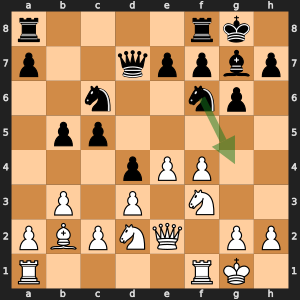

### [1/10] Nakamura, Hikaru vs Giri, Anish — Black plays Ng4

**Prev moves:** `10. Nbd2 d4 11. e4 b5 12. O-O Ng4`

**Parent context:** *Another strong preparatory move. There is no need to rush with:*

> Jumping in to the tempting e3-square.

#### Extraction [INCLUDED]

1. Ng4 prepares a jump to e3.

---

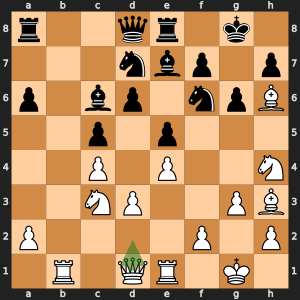

### [2/10] Ragger, Markus vs Tomczak, Jacek — White plays Qd2

**Prev moves:** `13... g6 14. Bh6 Re8 15. Bh3 Nbd7 16. Qd2`

**Parent context:** *now Black has to do something with his b7-bishop,*

> 16. Qd2 with some advantage, Priehoda, V (2425)-Chiburdanidze, M (2516) Batumi 2002, ½-½ (22), Nd5 and f4 are both possible.

#### Extraction [INCLUDED]

1. After Qd2, White can play Nd5.
2. After Qd2, White can play f4.

---

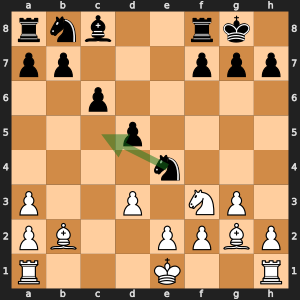

### [3/10] Richardson, Keith B vs Pokorna, Regina — Black plays Nc5

**Prev moves:** `9. bxa3 O-O 10. Bb2 Ne4 11. d3 Nc5`

**Parent context:** *What's the problem here? Can't White achieve anything?*

> 11...Nc5 with a sound game White's bishops aren't doing much.

#### Extraction [EXCLUDED: Commentary is mostly evaluative and vague; it gives no concrete move-specific fact beyond a general assessment of White's bishops.]

---

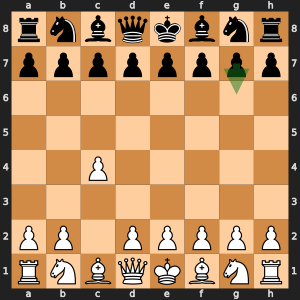

### [4/10] Hodgson, Julian M vs Efimov, Igor — Black plays g6 (alternative to Nf6)

**Prev moves:** `1. c4 g6`

> 1...g6 might be more accurate, as White could no longer play the game's system.

#### Extraction [EXCLUDED: Commentary is too vague and gives no concrete positional explanation beyond a generic assessment.]

---

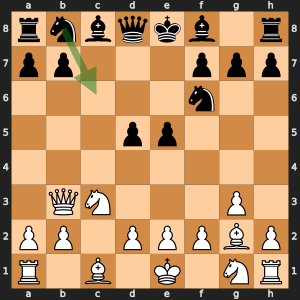

### [5/10] Kapostas, Z. vs Kallai, Gabor — Black plays Nc6

**Prev moves:** `4. Nc3 d5 5. cxd5 cxd5 6. Qb3 Nc6`

**Parent context:** *Known as the Keres System, this is a very logical counter to White's last move, because Black's c6-pawn blunts the effect of the opponent's bishop which is about to be fianchettoed on the long h1-a8 diagonal.*

> The gambit that goes with Nc6 is known to be strong for Black, as he will get a powerful lead in development in return for sacrificing his d5-pawn.

#### Extraction [INCLUDED]

1. Nc6 supports a gambit in which Black may sacrifice the d5-pawn.
2. In return for the d5-pawn, Black gets a powerful lead in development.

---

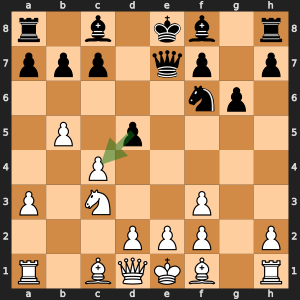

### [6/10] Harikrishna, Pentala vs Mamedyarov, Shakhriyar — Black plays dxc4

**Prev moves:** `7. Nxe5 Qe7 8. Nf3 Nxf3+ 9. gxf3 dxc4`

**Parent context:** *, for example,*

> 9...dxc4 Nevertheless, there's still much to be discovered here.

#### Extraction [EXCLUDED: The commentary gives no concrete move-specific explanation beyond a vague assessment.]

---

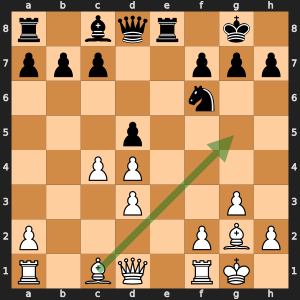

### [7/10] Nakamura, Hikaru vs Howell, David — White plays Bg5 (alternative to Be3)

**Prev moves:** `9... exd3 10. exd3 Nxd4 11. cxd4 d5 12. Bg5`

**Parent context:** *Howell plays directly through the center, fixing White's doubled d-pawns.*

> ? Now in fact

#### Extraction [EXCLUDED: Commentary is incomplete and contains no move-specific analyzable content.]

---

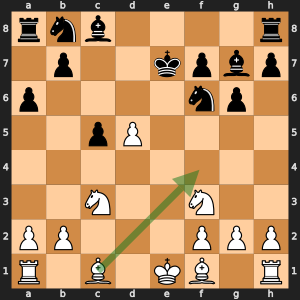

### [8/10] Epishin, Vladimir vs Gofshtein, Leonid D — White plays Bf4

**Prev moves:** `9... dxe5 10. Qxe5+ Qe7 11. Qxe7+ Kxe7 12. Bf4`

**Parent context:** *I can't find any previous examples of this move, but it's really not bad at all. White's crude idea is to exploit Black's lagging development with a very quick e4-e5. White's 'normal' moves are 8 a4, 8 h3 and 8 Bf4.*

> 12. Bf4 looks better for White.

#### Extraction [EXCLUDED: Commentary is only a vague evaluation with no concrete move-specific explanation.]

---

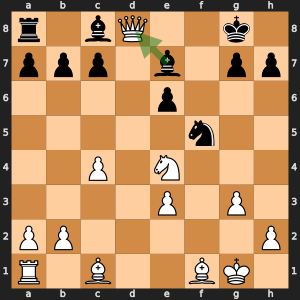

### [9/10] Sen, Subin vs Williams, Simon Kim — Black plays Bxd8

**Prev moves:** `13. e3 dxe4 14. Nxe4 Nf5 15. Qxd8+ Bxd8`

**Parent context:** *should not concern Black as White has taken the pressure off d5, for example,*

> 15...Bxd8 with an equal position.

#### Extraction [EXCLUDED: Commentary is only a generic evaluation with no concrete move-specific explanation.]

---

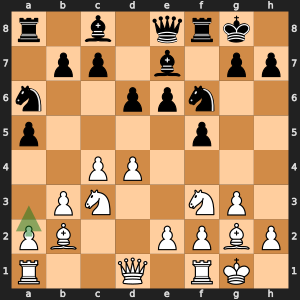

### [10/10] Vaulin, Alexander vs Obukhov, Alexander — White plays a3

**Prev moves:** `7... a5 8. b3 Na6 9. Bb2 Qe8 10. a3`

> A simple move but an effective way of keeping the knight on a6 out of play.

#### Extraction [INCLUDED]

1. a3 keeps Black's knight on a6 out of play.

---

In [70]:
# ── Config (change these and re-run just this cell) ──
SEED = 42
NUM_POSITIONS = 10

rng = random.Random(SEED)
sample_indices = rng.sample(range(len(all_entries)), NUM_POSITIONS)
samples = [all_entries[i] for i in sorted(sample_indices)]

print(f'Sampled {NUM_POSITIONS} positions (seed={SEED})')
for i, e in enumerate(samples):
    tag = 'ML' if e['is_mainline'] else f'V(d={e["variation_depth"]})'
    ml = f' [alt to {e["mainline_move"]}]' if e.get('mainline_move') else ''
    print(f'  [{i}] {tag}{ml} {e["game"]} — {e["move_san"]}  ({len(e["annotation"])} chars)')

for idx, entry in enumerate(samples):
    board = chess.Board(entry['fen'])
    move = chess.Move.from_uci(entry['move_uci'])
    move_san = board.san(move)
    turn = 'White' if board.turn == chess.WHITE else 'Black'

    # Run extraction
    raw_text = generate_extraction(entry)
    parsed = parse_json_output(raw_text)

    # Post-process filter
    pp_include, pp_reason = postprocess_filter(parsed)
    if not pp_include and parsed.get('include', True):
        parsed['include'] = False
        parsed['exclude_reason'] = pp_reason

    # ── Display ──
    svg = chess.svg.board(board, arrows=[(move.from_square, move.to_square)], size=300)
    display(SVG(svg))

    meta = entry.get('metadata', {})
    game = meta.get('White', '?') + ' vs ' + meta.get('Black', '?')

    # Title with variation info
    title = f'### [{idx+1}/{len(samples)}] {game} — {turn} plays {move_san}'
    if entry.get('mainline_move'):
        title += f' (alternative to {entry["mainline_move"]})'
    display(Markdown(title))

    if entry.get('prev_moves'):
        display(Markdown(f'**Prev moves:** `{entry["prev_moves"]}`'))

    if entry.get('parent_comment'):
        display(Markdown(f'**Parent context:** *{entry["parent_comment"]}*'))

    display(Markdown(f'> {entry["annotation"]}'))

    # Extraction result
    included = parsed.get('include', False)
    tag = 'INCLUDED' if included else f'EXCLUDED: {parsed.get("exclude_reason", "?")}'
    display(Markdown(f'#### Extraction [{tag}]'))

    reasoning = parsed.get('reasoning', [])
    if reasoning:
        display(Markdown('\n'.join(f'{i+1}. {a}' for i, a in enumerate(reasoning))))

    alt = parsed.get('alternative')
    if alt:
        alts = alt if isinstance(alt, list) else [alt]
        for a in alts:
            r_list = a.get('reasoning', [])
            display(Markdown(
                f'**Alternative: {a.get("move", "?")}**\n' +
                '\n'.join(f'  - {r}' for r in r_list)
            ))

    if parsed.get('variation'):
        display(Markdown(f'**Variation:** `{parsed["variation"]}`'))

    display(Markdown('---'))

Sampled 10 positions (seed=43)
  [0] ML Moussard, Jules vs Bacrot, Etienne — Nb4  (118 chars)
  [1] V(d=1) [alt to c5] Movsesian, Sergei vs Dubov, Daniil — Be2  (28 chars)
  [2] V(d=1) Kosten, Anthony C vs Griffiths, Ryan Rhys — Rec8  (61 chars)
  [3] V(d=3) Michalik, Peter vs Socko, Bartosz — Qxf6  (170 chars)
  [4] V(d=1) Zhou, Jianchao vs Yu, Yangyi — Nd4  (303 chars)
  [5] V(d=1) Nabaty, Tamir vs Loncar, Robert — Rhf1  (119 chars)
  [6] V(d=2) Abasov, Nijat vs Caruana, Fabiano — f5  (36 chars)
  [7] ML Kononenko, Tatiana vs Krasenkow, Michal — Qd4  (138 chars)
  [8] ML Harikrishna, Pentala vs Zhang, Zhong — Kf6  (96 chars)
  [9] V(d=1) Barus, Cerdas vs Dao, Thien Hai — Qd8  (79 chars)


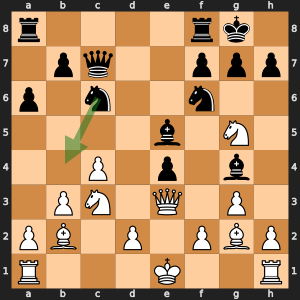

### [1/10] Moussard, Jules vs Bacrot, Etienne — Black plays Nb4

**Prev moves:** `13. Ng5 Be5 14. Nc3 Bg4 15. Qe3 Nb4`

**Parent context:** *Black's pieces develop with gain of tempo and meanwhile White still hasn't managed to castle and finish his development.*

> This looks very strong, threatening both ...Nd3+ and also ...Nc2, trapping the white queen, but White has a nice save.

#### Extraction [EXCLUDED: Commentary is too vague and only states threats without enough concrete move-specific explanation beyond a brief tactical label.]

---

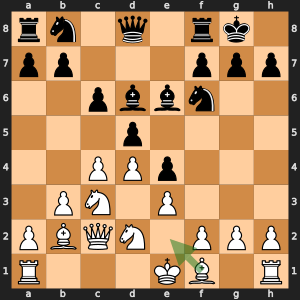

### [2/10] Movsesian, Sergei vs Dubov, Daniil — White plays Be2 (alternative to c5)

**Prev moves:** `7... e5 8. d4 e4 9. Nd2 Be6 10. Be2`

**Parent context:** *A smart choice, and a novelty, too.*

> 10. Be2 is more normal, i.e.

#### Extraction [EXCLUDED: Commentary is too vague and provides no concrete move-specific explanation beyond calling the move more normal.]

---

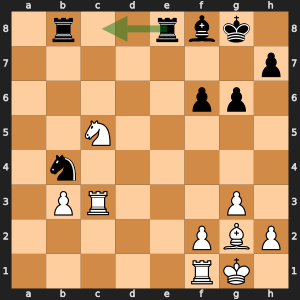

### [3/10] Kosten, Anthony C vs Griffiths, Ryan Rhys — Black plays Rec8

**Prev moves:** `26. Nxa5 Bxd6 27. Nxb7 Bf8 28. Nxc5 Rec8`

**Parent context:** *can simply be answered by*

> 28...Rec8 and it will be very difficult to make any progress.

#### Extraction [EXCLUDED: The commentary is only a vague evaluation of the resulting position and gives no concrete move-specific reason, threat, square, or plan.]

---

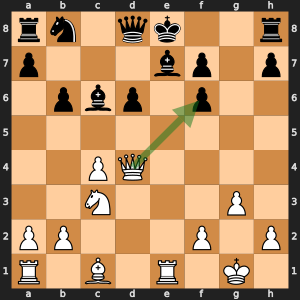

### [4/10] Michalik, Peter vs Socko, Bartosz — White plays Qxf6

**Prev moves:** `11... Bxg2 12. exf6 gxf6 13. Qxd4 Bc6 14. Qxf6`

**Parent context:** *and now:*

> Juergens,K (2161)-Georgiev,G (2107) Austria 2016 1-0 (25) , and now: 14... Rg8 (allows Black to hold on. If) 15. Bg5 Rxg5 16. Qxg5 Kf8 (there is nothing clear for White.)

#### Extraction [INCLUDED]

1. After Qxf6, Black can play Rg8 to hold the position.
2. If White continues with Bg5, then Rxg5 Qxg5 Kf8 leaves White without anything clear.

**Alternative: Rg8**
  - Rg8 allows Black to hold on.
  - After Bg5 Rxg5 Qxg5 Kf8, White has no clear continuation.

---

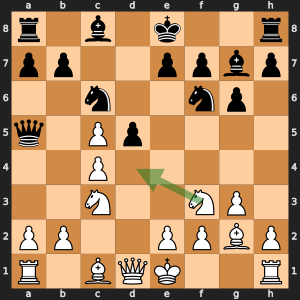

### [5/10] Zhou, Jianchao vs Yu, Yangyi — White plays Nd4

**Prev moves:** `5... g6 6. Bg2 Bg7 7. dxc5 Qa5 8. Nd4`

**Parent context:** *playing in Grunfeld style looks good but White has a strong resource*

> 8. Nd4 other moves bring no problems for Black: 8... Nxd4 9. Qxd4 Nh5 10. Qd2 dxc4 11. c6 (again this annoying move) Rb8 12. O-O O-O 13. Nd5 Qxd2 14. Nxe7+; or 8... Ne4 (is strongly refuted by) 9. Nxc6 bxc6 10. O-O Nxc3 11. bxc3 e6 12. cxd5 exd5 13. Bxd5 (otherwise everything would be ok) cxd5 14. Qxd5

#### Extraction [INCLUDED]

1. Nd4 is a strong resource in this position.
2. After ...Nxd4 and Qxd4, White has the annoying c6 advance available.
3. After ...Ne4, White can answer Nxc6 followed by O-O and later Bxd5, which strongly refutes that setup.

**Alternative: Ne4**
  - Ne4 is strongly refuted by White's sequence Nxc6, O-O, cxd5, and Bxd5.
  - Without Bxd5, everything would be okay for Black.

**Variation:** `8...Nxd4 9.Qxd4 Nh5 10.Qd2 dxc4 11.c6 Rb8 12.O-O O-O 13.Nd5 Qxd2 14.Nxe7+`

---

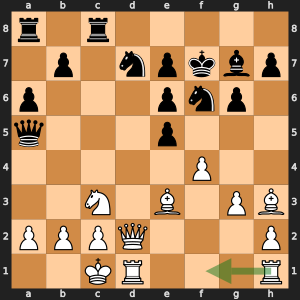

### [6/10] Nabaty, Tamir vs Loncar, Robert — White plays Rhf1

**Prev moves:** `13... Qa5 14. f4 Rhc8 15. e5 dxe5 16. Rhf1`

**Parent context:** *would just have been pretty strong. The main point is the quiet follow-up*

> 16. Rhf1 when: 16... exf4 17. Bxf4 Nc5 18. Qe3 (leaves White in control of the position, if without an immediate kill.)

#### Extraction [EXCLUDED: Commentary is a short continuation with only a vague assessment and no concrete explanation of the move beyond the line itself.]

---

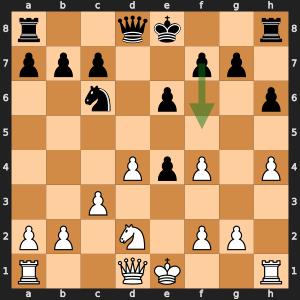

### [7/10] Abasov, Nijat vs Caruana, Fabiano — Black plays f5

**Prev moves:** `11. Bxe4 dxe4 12. Nd2 Bxf4 13. exf4 f5`

**Parent context:** *(this looks rock-solid for Black the knight on c6 is arguably slightly misplaced, but so is the one on f3)*

> 13...f5 should just have been met by

#### Extraction [EXCLUDED: The commentary is incomplete and gives no concrete explanation of the move.]

---

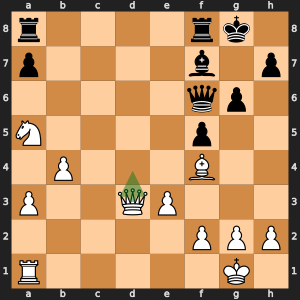

### [8/10] Kononenko, Tatiana vs Krasenkow, Michal — White plays Qd4

**Prev moves:** `21... Nxd3 22. Qxd3 Bxa1 23. Rxa1 Qf6 24. Qd4`

**Parent context:** *Making sure that White doesn't dominate the long dark diagonal.*

> A slightly committal decision but otherwise Black's rooks would come to the central files and White would lose control of the open centre.

#### Extraction [EXCLUDED: Commentary is mostly evaluative and vague; it does not give a concrete square-specific explanation of the move beyond general control of the center.]

---

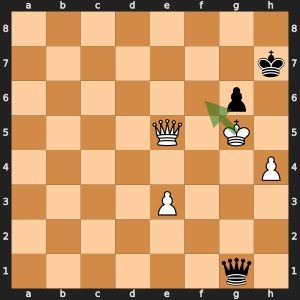

### [9/10] Harikrishna, Pentala vs Zhang, Zhong — White plays Kf6

**Prev moves:** `92... Qc1 93. Qe5+ Kh7 94. Kg5 Qg1+ 95. Kf6`

**Parent context:** *White now has a passed e-pawn and more space for his king to wriggle about.*

> Penetrating Black's camp and creating both mating threats and the possibility of 'cross-checks'.

#### Extraction [INCLUDED]

1. Kf6 penetrates into Black's position.
2. Kf6 creates mating threats.
3. Kf6 also creates the possibility of cross-checks.

---

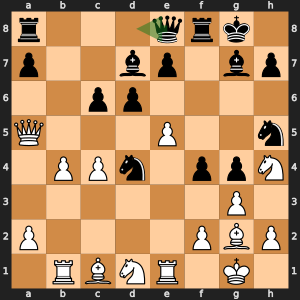

### [10/10] Barus, Cerdas vs Dao, Thien Hai — Black plays Qd8

**Prev moves:** `17. Re1 Nh5 18. Nd1 Nd4 19. e5 Qd8`

**Parent context:** *(aggressive)*

> Bouwmeester, H-Ioseliani, N Munich 2000, left Black with the more dynamic play.

#### Extraction [EXCLUDED: The commentary is only a game reference and vague evaluation, with no concrete move-specific explanation.]

---

In [71]:
# ── Config (change these and re-run just this cell) ──
SEED = 43
NUM_POSITIONS = 10

rng = random.Random(SEED)
sample_indices = rng.sample(range(len(all_entries)), NUM_POSITIONS)
samples = [all_entries[i] for i in sorted(sample_indices)]

print(f'Sampled {NUM_POSITIONS} positions (seed={SEED})')
for i, e in enumerate(samples):
    tag = 'ML' if e['is_mainline'] else f'V(d={e["variation_depth"]})'
    ml = f' [alt to {e["mainline_move"]}]' if e.get('mainline_move') else ''
    print(f'  [{i}] {tag}{ml} {e["game"]} — {e["move_san"]}  ({len(e["annotation"])} chars)')

for idx, entry in enumerate(samples):
    board = chess.Board(entry['fen'])
    move = chess.Move.from_uci(entry['move_uci'])
    move_san = board.san(move)
    turn = 'White' if board.turn == chess.WHITE else 'Black'

    # Run extraction
    raw_text = generate_extraction(entry)
    parsed = parse_json_output(raw_text)

    # Post-process filter
    pp_include, pp_reason = postprocess_filter(parsed)
    if not pp_include and parsed.get('include', True):
        parsed['include'] = False
        parsed['exclude_reason'] = pp_reason

    # ── Display ──
    svg = chess.svg.board(board, arrows=[(move.from_square, move.to_square)], size=300)
    display(SVG(svg))

    meta = entry.get('metadata', {})
    game = meta.get('White', '?') + ' vs ' + meta.get('Black', '?')

    # Title with variation info
    title = f'### [{idx+1}/{len(samples)}] {game} — {turn} plays {move_san}'
    if entry.get('mainline_move'):
        title += f' (alternative to {entry["mainline_move"]})'
    display(Markdown(title))

    if entry.get('prev_moves'):
        display(Markdown(f'**Prev moves:** `{entry["prev_moves"]}`'))

    if entry.get('parent_comment'):
        display(Markdown(f'**Parent context:** *{entry["parent_comment"]}*'))

    display(Markdown(f'> {entry["annotation"]}'))

    # Extraction result
    included = parsed.get('include', False)
    tag = 'INCLUDED' if included else f'EXCLUDED: {parsed.get("exclude_reason", "?")}'
    display(Markdown(f'#### Extraction [{tag}]'))

    reasoning = parsed.get('reasoning', [])
    if reasoning:
        display(Markdown('\n'.join(f'{i+1}. {a}' for i, a in enumerate(reasoning))))

    alt = parsed.get('alternative')
    if alt:
        alts = alt if isinstance(alt, list) else [alt]
        for a in alts:
            r_list = a.get('reasoning', [])
            display(Markdown(
                f'**Alternative: {a.get("move", "?")}**\n' +
                '\n'.join(f'  - {r}' for r in r_list)
            ))

    if parsed.get('variation'):
        display(Markdown(f'**Variation:** `{parsed["variation"]}`'))

    display(Markdown('---'))